In [ ]:
import pandas as pd
import numpy as np

# visualización
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
df = pd.read_csv("./tablas_silver/silver_feature_set_ml.csv")

df.head()

,id,fecha_venta,id_sku,descripcion,categoria,id_canal,lead_time_dias,cantidad_vendida,inversion_usd,inversion_usd_lag1,inversion_usd_lag2,temperatura_promedio_celsius,dia_semana
0,1,2024-01-01,SKU_1L,Botella_1L,Personal,CH01,2,128,0.000000,0.000000,0.000000,NaN,0
1,2,2024-01-08,SKU_1L,Botella_1L,Personal,CH01,2,155,157.792562,0.000000,0.000000,18.273525,0
2,3,2024-01-19,SKU_1L,Botella_1L,Personal,CH01,2,220,265.692164,157.792562,0.000000,25.726616,4
3,4,2024-01-26,SKU_1L,Botella_1L,Personal,CH01,2,248,297.341440,265.692164,157.792562,33.059047,4
4,5,2024-01-27,SKU_1L,Botella_1L,Personal,CH01,2,253,135.532950,297.341440,265.692164,19.592497,5


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            858 non-null    int64  
 1   fecha_venta                   858 non-null    str    
 2   id_sku                        858 non-null    str    
 3   descripcion                   858 non-null    str    
 4   categoria                     858 non-null    str    
 5   id_canal                      858 non-null    str    
 6   lead_time_dias                858 non-null    int64  
 7   cantidad_vendida              858 non-null    int64  
 8   inversion_usd                 858 non-null    float64
 9   inversion_usd_lag1            858 non-null    float64
 10  inversion_usd_lag2            858 non-null    float64
 11  temperatura_promedio_celsius  855 non-null    float64
 12  dia_semana                    858 non-null    int64  
dtypes: float64(4), i

In [24]:
df_model = df.drop(columns=[
    'id',
    'fecha_venta',
    'id_sku',
    'descripcion',
    'categoria'
])

df_model.head()

,id_canal,lead_time_dias,cantidad_vendida,inversion_usd,inversion_usd_lag1,inversion_usd_lag2,temperatura_promedio_celsius,dia_semana
0,CH01,2,128,0.000000,0.000000,0.000000,NaN,0
1,CH01,2,155,157.792562,0.000000,0.000000,18.273525,0
2,CH01,2,220,265.692164,157.792562,0.000000,25.726616,4
3,CH01,2,248,297.341440,265.692164,157.792562,33.059047,4
4,CH01,2,253,135.532950,297.341440,265.692164,19.592497,5


In [25]:
df_model.isnull().sum()

id_canal                        0
lead_time_dias                  0
cantidad_vendida                0
inversion_usd                   0
inversion_usd_lag1              0
inversion_usd_lag2              0
temperatura_promedio_celsius    3
dia_semana                      0
dtype: int64

In [26]:
df_model = df_model.dropna()

In [27]:
df_model.isnull().sum()

id_canal                        0
lead_time_dias                  0
cantidad_vendida                0
inversion_usd                   0
inversion_usd_lag1              0
inversion_usd_lag2              0
temperatura_promedio_celsius    0
dia_semana                      0
dtype: int64

In [28]:
#Separar variable objetivo (Target)
X = df_model.drop(columns=['cantidad_vendida'])
y = df_model['cantidad_vendida']

In [29]:
#Identificar variables numéricas y categóricas
numerical_features = [
    'inversion_usd',
    'inversion_usd_lag1',
    'inversion_usd_lag2',
    'lead_time_dias',
    'temperatura_promedio_celsius'
]

categorical_features = [
    'id_canal',
    'dia_semana'
]

In [30]:
#Crear transformación (Escalamiento + Dummies)
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [31]:
#dividir datos entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (684, 7)
Test: (171, 7)


In [33]:
#Crear modelos a evaluar
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [34]:
#Entrenar modelos
results = []

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df

,Modelo,MAE,RMSE,R2
0,Linear Regression,56.736677,81.692740,0.342194
1,Random Forest,59.230326,87.404810,0.246988
2,Gradient Boosting,55.123398,85.895025,0.272778


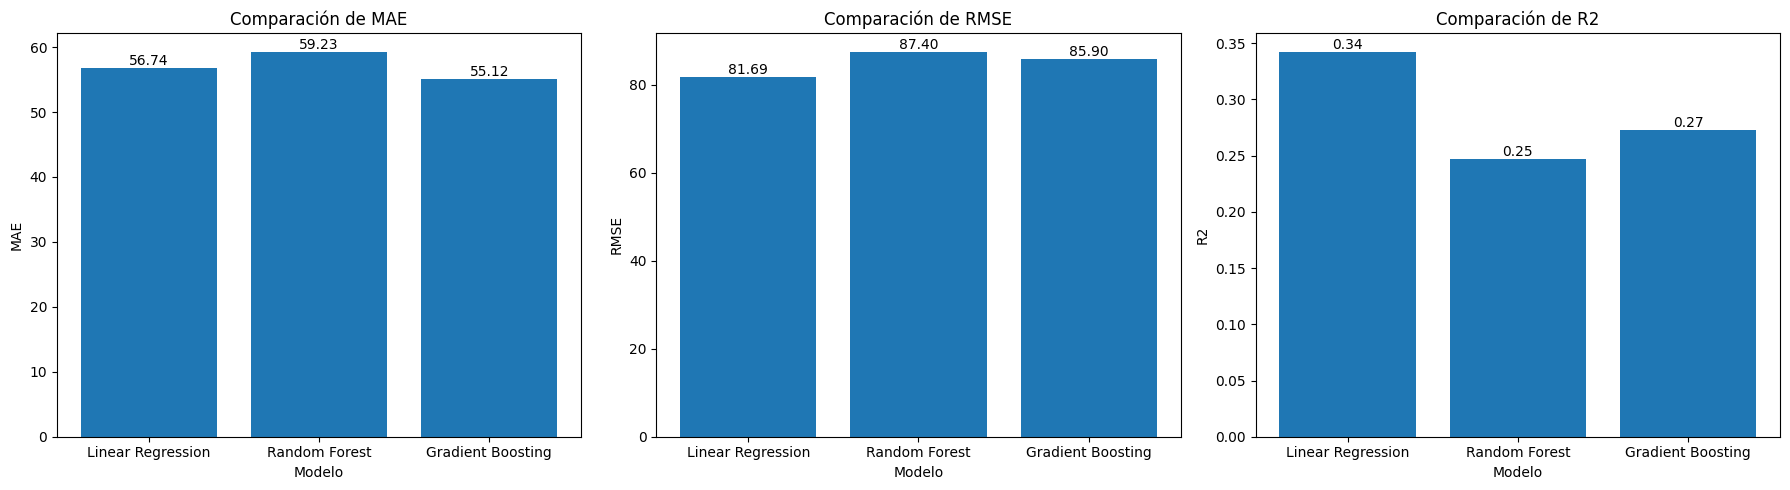

In [38]:
# Graficar métricas de los modelos

import matplotlib.pyplot as plt
import numpy as np

metrics = ['MAE', 'RMSE', 'R2']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, metric in enumerate(metrics):
    
    ax = axes[i]
    
    bars = ax.bar(results_df['Modelo'], results_df[metric])
    
    ax.set_title(f'Comparación de {metric}')
    ax.set_xlabel('Modelo')
    ax.set_ylabel(metric)
    
    # agregar etiquetas sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [36]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
0,num__inversion_usd,0.426302
4,num__temperatura_promedio_celsius,0.137764
2,num__inversion_usd_lag2,0.132574
1,num__inversion_usd_lag1,0.124265
5,cat__id_canal_CH01,0.024171
6,cat__id_canal_CH02,0.022638
9,cat__dia_semana_0,0.022486
3,num__lead_time_dias,0.020653
7,cat__id_canal_CH03,0.020245
10,cat__dia_semana_1,0.015603


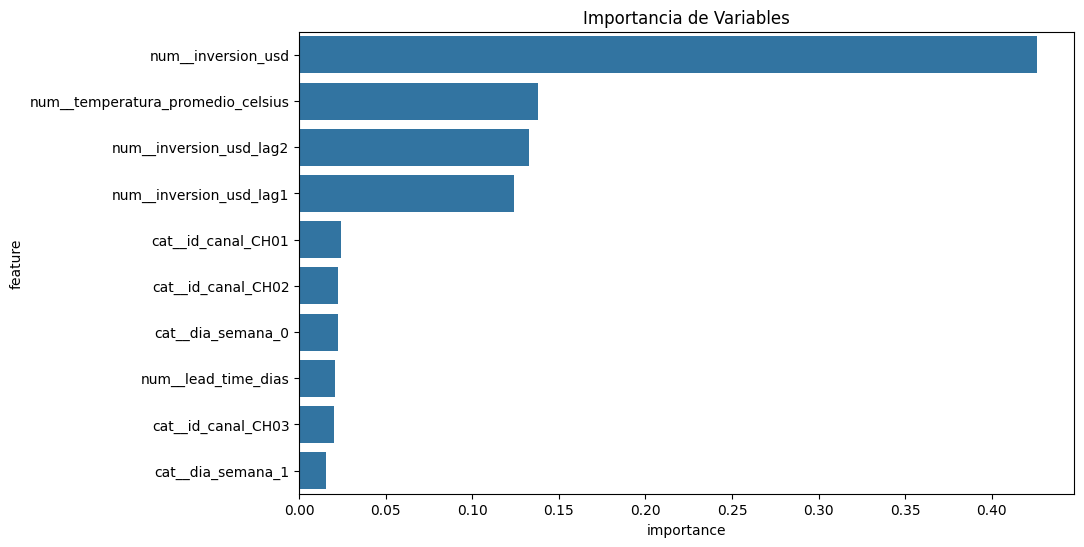

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title("Importancia de Variables")
plt.show()

In [39]:
# entrenar modelo final (Linear Regression)

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

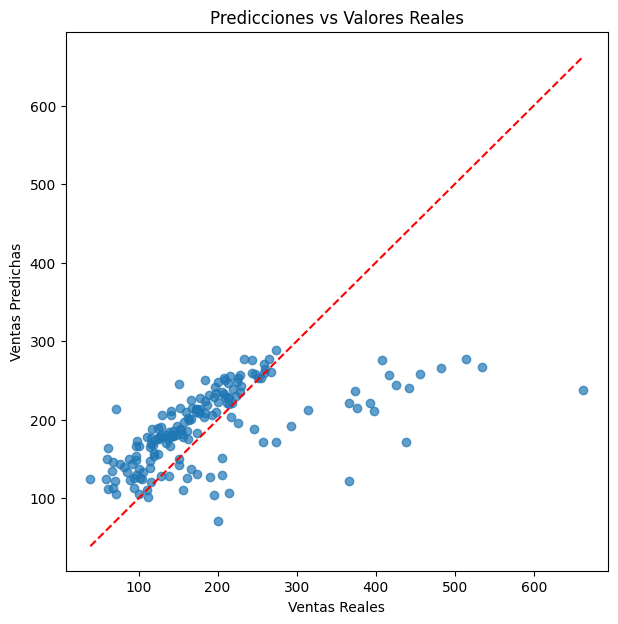

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.title("Predicciones vs Valores Reales")

plt.show()

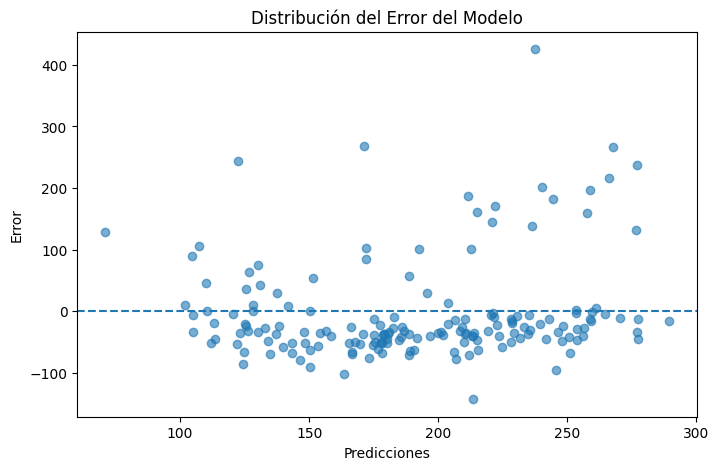

In [41]:
errores = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, errores, alpha=0.6)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicciones")
plt.ylabel("Error")
plt.title("Distribución del Error del Modelo")

plt.show()

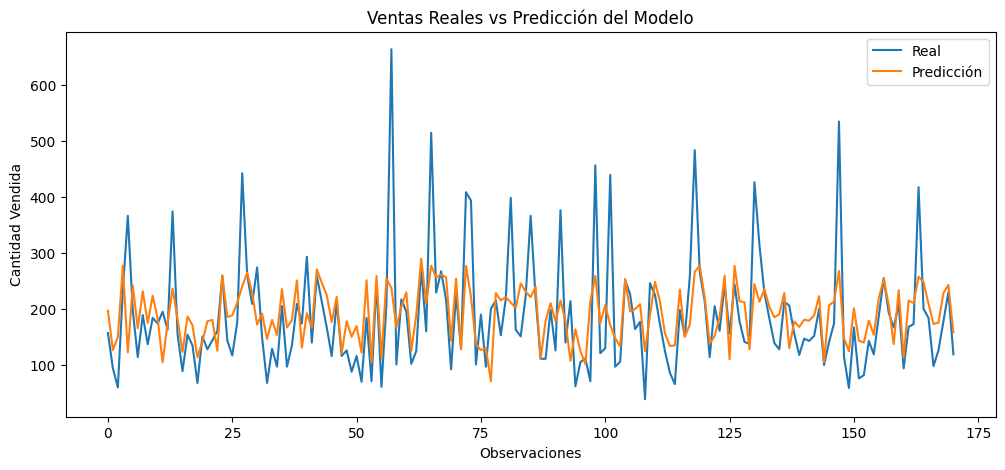

In [42]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Predicción")

plt.legend()
plt.title("Ventas Reales vs Predicción del Modelo")
plt.xlabel("Observaciones")
plt.ylabel("Cantidad Vendida")

plt.show()